# Fast Offline DQN Pipeline

This notebook builds a correct and fast data pipeline for offline DQN training on Box Moving.

The focus is on reducing Python overhead, keeping batch construction JAX-friendly, and running the training loop with `jax.lax.scan`.

In [1]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
from __future__ import annotations

from pathlib import Path
import sys
import time
from typing import Any

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import ml_collections
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "pyproject.toml").exists() else NOTEBOOK_DIR.parent
SRC_ROOT = REPO_ROOT / "src"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from config import Config, ExpConfig
from envs import create_env
from envs.block_moving.block_moving_env import BoxMovingEnv
from envs.block_moving.env_types import BoxMovingConfig, remove_targets
from envs.block_moving.input_features import encode_grid_inputs
from envs.block_moving.wrappers import wrap_for_eval
from impls.agents import create_agent, default_config
from impls.utils.checkpoints import save_agent
from train import collect_data

## Configure Paths and Reproducibility

Set the dataset path, output directory, random seed, and runtime settings up front so the notebook is deterministic and easy to rerun.

In [3]:
DATASET_PATH = REPO_ROOT / "data" / "expert_default_4x4_2boxes_10000traj_parallel512_fixed100.npy"
OUTPUT_DIR = REPO_ROOT / "runs" / "fast_offline_dqn_pipeline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
BATCH_SIZE = 512
NUM_UPDATES = 100_000
LOG_EVERY = 100
EVAL_EVERY = 500
NUM_EVAL_ENVS = 32
INPUT_REPRESENTATION = "one_hot_flat"
USE_TARGETS = False
DISCOUNT = 0.99
VALUE_P_CURGOAL = 0.2
VALUE_P_TRAJGOAL = 0.5
VALUE_P_RANDOMGOAL = 0.3

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print(f"Dataset path: {DATASET_PATH}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Seed: {SEED}")
print(f"Batch size: {BATCH_SIZE}")

Dataset path: /home/mbortkie/repos/golden-standard/data/expert_default_4x4_2boxes_10000traj_parallel512_fixed100.npy
Output dir: /home/mbortkie/repos/golden-standard/runs/fast_offline_dqn_pipeline
Seed: 0
Batch size: 512


## Load Raw Data

Load the saved offline trajectories and inspect a few basic properties before preprocessing.

In [4]:
def load_dataset(path: str | Path) -> dict:
    path = Path(path).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")
    data = np.load(path, allow_pickle=True)
    if hasattr(data, "item"):
        data = data.item()
    if not isinstance(data, dict):
        raise TypeError("Expected a dict saved in .npy format")
    return data


def extract_trajectories(dataset: dict) -> list[dict[str, Any]]:
    trajectories = dataset.get("trajectories")
    if trajectories is None:
        raise KeyError("Dataset does not contain a 'trajectories' field")
    if isinstance(trajectories, np.ndarray):
        return [dict(traj) for traj in trajectories.tolist()]
    return [dict(traj) for traj in trajectories]


dataset = load_dataset(DATASET_PATH)
trajectories = extract_trajectories(dataset)
summary_row = {
    'num_trajectories': len(trajectories),
    'mean_executed_steps': float(np.mean([t.get('executed_steps', 0) for t in trajectories])) if trajectories else np.nan,
    'mean_success': float(np.mean([t.get('success', False) for t in trajectories])) if trajectories else np.nan,
}
print(f"Loaded trajectories: {len(trajectories)}")
print(f"Dataset keys: {sorted(dataset.keys())}")
display(pd.DataFrame([summary_row]))
print("First trajectory action sample:", np.asarray(trajectories[0]["actions"])[:12] if trajectories else [])

Loaded trajectories: 10000
Dataset keys: ['config', 'summary', 'trajectories', 'transition_view']


,num_trajectories,mean_executed_steps,mean_success
0,10000,100.0,1.0


First trajectory action sample: [2 4 0 0 5 1 1 1 4 0 0 3]


## Define Preprocessing Steps

Pack trajectories into dense arrays once, then sample indices from JAX during training instead of rebuilding batches in Python.

In [5]:
def build_tensor_cache(trajectories: list[dict[str, Any]]) -> dict[str, np.ndarray]:
    if not trajectories:
        raise ValueError("No trajectories were loaded")

    max_length = max(int(traj.get("executed_steps", len(traj.get("actions", [])))) for traj in trajectories)
    first_obs = np.asarray(trajectories[0]["observations"])
    if first_obs.ndim == 3:
        grid_shape = tuple(first_obs.shape[1:])
    elif first_obs.ndim == 2:
        side = int(np.sqrt(first_obs.shape[1]))
        grid_shape = (side, side)
    else:
        raise ValueError("Unsupported observation shape")

    num_traj = len(trajectories)
    observations = np.zeros((num_traj, max_length, *grid_shape), dtype=np.int8)
    next_observations = np.zeros_like(observations)
    actions = np.zeros((num_traj, max_length), dtype=np.int32)
    rewards = np.zeros((num_traj, max_length), dtype=np.float32)
    valid_mask = np.zeros((num_traj, max_length), dtype=np.bool_)
    lengths = np.zeros((num_traj,), dtype=np.int32)

    flat_traj_idx = []
    flat_step_idx = []

    for traj_idx, traj in enumerate(trajectories):
        obs = np.asarray(traj["observations"], dtype=np.int8)
        next_obs = np.asarray(traj["next_observations"], dtype=np.int8)
        act = np.asarray(traj["actions"], dtype=np.int32)
        rew = np.asarray(traj["rewards"], dtype=np.float32)
        valid_steps = min(
            int(traj.get("effective_steps", obs.shape[0])),
            obs.shape[0],
            next_obs.shape[0],
            act.shape[0],
            rew.shape[0],
            max_length,
        )
        if valid_steps <= 1:
            continue

        observations[traj_idx, :valid_steps] = obs[:valid_steps]
        next_observations[traj_idx, :valid_steps] = next_obs[:valid_steps]
        actions[traj_idx, :valid_steps] = act[:valid_steps]
        rewards[traj_idx, :valid_steps] = rew[:valid_steps]
        valid_mask[traj_idx, :valid_steps] = True
        lengths[traj_idx] = valid_steps
        flat_traj_idx.extend([traj_idx] * (valid_steps - 1))
        flat_step_idx.extend(list(range(valid_steps - 1)))

    flat_traj_idx = np.asarray(flat_traj_idx, dtype=np.int32)
    flat_step_idx = np.asarray(flat_step_idx, dtype=np.int32)
    if flat_traj_idx.size == 0:
        raise ValueError("No valid transitions found in the dataset")

    return {
        "observations": observations,
        "next_observations": next_observations,
        "actions": actions,
        "rewards": rewards,
        "valid_mask": valid_mask,
        "lengths": lengths,
        "flat_traj_idx": flat_traj_idx,
        "flat_step_idx": flat_step_idx,
        "num_transitions": np.int32(flat_traj_idx.shape[0]),
    }


cache = build_tensor_cache(trajectories)
print(f"Cache shapes: obs={cache['observations'].shape}, actions={cache['actions'].shape}")
print(f"Valid transitions: {int(cache['num_transitions'])}")

Cache shapes: obs=(10000, 100, 4, 4), actions=(10000, 100)
Valid transitions: 990000


## Build the Fast Pipeline

Construct a JAX-based sampler and a jitted training scan so each update stays on device.

In [6]:
cache_jax = jax.tree_util.tree_map(lambda x: jnp.asarray(x), cache)


def sample_batch_jax(
    key: jax.Array,
    cache: dict[str, jax.Array],
    batch_size: int,
    input_representation: str,
    use_targets: bool,
    value_p_curgoal: float = 0.2,
    value_p_trajgoal: float = 0.5,
    value_p_randomgoal: float = 0.3,
    discount: float = 0.99,
) -> dict[str, jax.Array]:
    if not np.isclose(value_p_curgoal + value_p_trajgoal + value_p_randomgoal, 1.0):
        raise ValueError("Goal sampling probabilities must sum to 1.0")

    key, flat_key, goal_type_key, random_goal_key, offset_key = jax.random.split(key, 5)
    num_transitions = cache["num_transitions"]
    flat_indices = jax.random.randint(flat_key, (batch_size,), 0, num_transitions)
    traj_idx = cache["flat_traj_idx"][flat_indices]
    step_idx = cache["flat_step_idx"][flat_indices]

    observations = cache["observations"][traj_idx, step_idx]
    next_observations = cache["next_observations"][traj_idx, step_idx]
    actions = cache["actions"][traj_idx, step_idx]

    goal_selector = jax.random.uniform(goal_type_key, (batch_size,))
    trajgoal_end = value_p_curgoal + value_p_trajgoal

    current_goals = observations

    offsets = jax.random.geometric(offset_key, p=1.0 - discount, shape=(batch_size,))
    traj_lengths = cache["lengths"][traj_idx]
    traj_goal_steps = jnp.minimum(step_idx + offsets, jnp.maximum(traj_lengths - 1, 0))
    traj_goals = cache["observations"][traj_idx, traj_goal_steps]

    random_flat_indices = jax.random.randint(random_goal_key, (batch_size,), 0, num_transitions)
    random_traj_idx = cache["flat_traj_idx"][random_flat_indices]
    random_step_idx = cache["flat_step_idx"][random_flat_indices]
    random_goals = cache["observations"][random_traj_idx, random_step_idx]

    goals = jnp.where(goal_selector[:, None, None] < value_p_curgoal, current_goals, traj_goals)
    random_mask = goal_selector >= trajgoal_end
    goals = jnp.where(random_mask[:, None, None], random_goals, goals)

    reward = jax.vmap(BoxMovingEnv.get_reward)(observations, next_observations, goals)
    masks = jnp.ones_like(reward, dtype=jnp.float32)

    if not use_targets:
        observations = remove_targets(observations)
        next_observations = remove_targets(next_observations)
        goals = remove_targets(goals)

    return {
        "observations": encode_grid_inputs(observations, input_representation),
        "next_observations": encode_grid_inputs(next_observations, input_representation),
        "actions": actions.astype(jnp.int32),
        "rewards": reward.astype(jnp.float32),
        "masks": masks,
        "value_goals": encode_grid_inputs(goals, input_representation),
        "actor_goals": encode_grid_inputs(goals, input_representation),
    }


print("Sample batch shapes:")
batch_preview = sample_batch_jax(jax.random.PRNGKey(SEED + 1), cache_jax, 8, INPUT_REPRESENTATION, USE_TARGETS)
for name, value in batch_preview.items():
    print(name, tuple(value.shape), value.dtype)

Sample batch shapes:
observations (8, 192) float32
next_observations (8, 192) float32
actions (8,) int32
rewards (8,) float32
masks (8,) float32
value_goals (8, 192) float32
actor_goals (8, 192) float32


## Validate Pipeline Correctness

Run a small batch through the sampler and the training path to verify shapes, dtypes, and representative values.

In [ ]:
env_config = BoxMovingConfig(
    grid_size=4,
    number_of_boxes_min=2,
    number_of_boxes_max=2,
    number_of_moving_boxes_max=2,
    episode_length=100,
    level_generator="variable",
    generator_special=True,
    quarter_size=2,
)

agent_config = ml_collections.ConfigDict(dict(default_config))
agent_config.update(
    {
        "agent_name": "gcdqn",
        "lr": 3e-4,
        "batch_size": BATCH_SIZE,
        "actor_hidden_dims": (256, 256),
        "value_hidden_dims": (256, 256),
        "layer_norm": True,
        "discount": DISCOUNT,
        "tau": 0.005,
        "discrete": True,
        "encoder": None,
        "net_arch": "mlp",
        "action_sampling": "softmax",
        "target_entropy": -1.1,
        "target_entropy_multiplier": 0.5,
        "use_discounted_mc_rewards": False,
        "frame_stack": 1,
    }
)

exp_config = ExpConfig(
    name="fast_offline_dqn_pipeline",
    project="crl_subgoal",
    mode="disabled",
    num_envs=NUM_EVAL_ENVS,
    seed=SEED,
    input_representation=INPUT_REPRESENTATION,
    use_targets=USE_TARGETS,
    save_dir=str(OUTPUT_DIR),
)
config = Config(exp=exp_config, env=env_config, agent=agent_config)


def build_example_batch(cache: dict[str, np.ndarray]) -> dict[str, jax.Array]:
    observations = jnp.asarray(cache["observations"][0, :6])
    goals = jnp.asarray(cache["observations"][0, 1:7])
    if not USE_TARGETS:
        observations = remove_targets(observations)
        goals = remove_targets(goals)
    return {
        "observations": encode_grid_inputs(observations, INPUT_REPRESENTATION),
        "actions": jnp.arange(6, dtype=jnp.int32),
        "value_goals": encode_grid_inputs(goals, INPUT_REPRESENTATION),
    }


example_batch = build_example_batch(cache)
agent = create_agent(config.agent, example_batch, config.exp.seed)


def evaluate_policy(agent, key: jax.Array) -> dict[str, float]:
    _, _, timesteps = collect_data(
        agent,
        key,
        eval_env,
        config.exp.num_envs,
        config.env.episode_length,
        use_targets=config.exp.use_targets,
        input_representation=config.exp.input_representation,
    )
    timesteps = jax.tree_util.tree_map(lambda x: x.swapaxes(1, 0), timesteps)
    done_or_trunc = timesteps.done | timesteps.truncated
    terminal_mask = (jnp.cumsum(done_or_trunc.astype(jnp.int32), axis=1) == 1) & done_or_trunc
    terminal_rewards = timesteps.reward[terminal_mask]
    terminal_success = timesteps.success[terminal_mask]
    return {
        "eval/mean_reward": float(jax.device_get(terminal_rewards.mean())) if terminal_rewards.size else float("nan"),
        "eval/success_rate": float(jax.device_get(terminal_success.mean())) if terminal_success.size else float("nan"),
    }


eval_env = wrap_for_eval(create_env(config.env))
eval_env.step = jax.jit(jax.vmap(eval_env.step))
eval_env.reset = jax.jit(jax.vmap(eval_env.reset))


def train_scan(agent, key):
    def step_fn(carry, _):
        agent, key = carry
        key, batch_key = jax.random.split(key)
        batch = sample_batch_jax(
            batch_key,
            cache_jax,
            BATCH_SIZE,
            INPUT_REPRESENTATION,
            USE_TARGETS,
            value_p_curgoal=VALUE_P_CURGOAL,
            value_p_trajgoal=VALUE_P_TRAJGOAL,
            value_p_randomgoal=VALUE_P_RANDOMGOAL,
            discount=DISCOUNT,
        )
        agent, info = agent.update(batch)
        return (agent, key), info

    return jax.lax.scan(step_fn, (agent, key), xs=None, length=NUM_UPDATES)


print("Agent initialized")
print("Example batch shapes:")
for name, value in example_batch.items():
    print(name, tuple(value.shape), value.dtype)

Agent initialized
Example batch shapes:
observations (6, 192) float32
actions (6,) int32
value_goals (6, 192) float32


## Benchmark Pipeline Performance

Measure the sampler and training scan so you can confirm the notebook is actually fast, not just theoretically vectorized.

In [8]:
validation_batch = sample_batch_jax(
    jax.random.PRNGKey(SEED + 1),
    cache_jax,
    8,
    INPUT_REPRESENTATION,
    USE_TARGETS,
    value_p_curgoal=VALUE_P_CURGOAL,
    value_p_trajgoal=VALUE_P_TRAJGOAL,
    value_p_randomgoal=VALUE_P_RANDOMGOAL,
    discount=DISCOUNT,
)

print("Validation batch")
for name, value in validation_batch.items():
    print(f"{name:18s} shape={tuple(value.shape)} dtype={value.dtype}")

assert validation_batch["observations"].shape[0] == 8
assert validation_batch["actions"].dtype == jnp.int32
assert validation_batch["rewards"].dtype == jnp.float32
assert validation_batch["masks"].dtype == jnp.float32
assert jnp.all(validation_batch["masks"] == 1.0)
assert jnp.all((validation_batch["actions"] >= 0) & (validation_batch["actions"] < 6))

print("Validation passed")

Validation batch
observations       shape=(8, 192) dtype=float32
next_observations  shape=(8, 192) dtype=float32
actions            shape=(8,) dtype=int32
rewards            shape=(8,) dtype=float32
masks              shape=(8,) dtype=float32
value_goals        shape=(8, 192) dtype=float32
actor_goals        shape=(8, 192) dtype=float32
Validation passed


In [9]:
# Warm up JIT before timing.
_ = jax.tree_util.tree_map(lambda x: x.block_until_ready(), validation_batch)

sample_key = jax.random.PRNGKey(SEED + 2)
start = time.perf_counter()
for _ in range(50):
    batch = sample_batch_jax(
        sample_key,
        cache_jax,
        BATCH_SIZE,
        INPUT_REPRESENTATION,
        USE_TARGETS,
        value_p_curgoal=VALUE_P_CURGOAL,
        value_p_trajgoal=VALUE_P_TRAJGOAL,
        value_p_randomgoal=VALUE_P_RANDOMGOAL,
        discount=DISCOUNT,
    )
    sample_key, _ = jax.random.split(sample_key)
_ = jax.tree_util.tree_map(lambda x: x.block_until_ready(), batch)
sample_elapsed = time.perf_counter() - start

train_key = jax.random.PRNGKey(SEED + 3)
train_fn = jax.jit(lambda agent, key: train_scan(agent, key))
start = time.perf_counter()
(final_agent, _), train_logs = train_fn(agent, train_key)
train_logs = jax.tree_util.tree_map(lambda x: x.block_until_ready(), train_logs)
train_elapsed = time.perf_counter() - start

print(f"Sample batch time for 50 batches: {sample_elapsed:.3f}s")
print(f"Training scan time for {NUM_UPDATES} updates: {train_elapsed:.3f}s")
print(f"Updates/sec: {NUM_UPDATES / train_elapsed:.1f}")

train_log_df = pd.DataFrame(jax.device_get(train_logs))
train_log_df.insert(0, "step", np.arange(1, len(train_log_df) + 1))
display(train_log_df.head())

Sample batch time for 50 batches: 2.185s
Training scan time for 100000 updates: 35.218s
Updates/sec: 2839.5


,step,critic/alpha_temp,critic/alpha_temp_loss,critic/critic_loss,critic/entropy,critic/entropy_std,critic/q.std,critic/q_max,critic/q_mean,critic/q_min,grad/max,grad/min,grad/norm
0,1,1.000000,0.469575,2.843216,1.785245,0.003660,0.766098,1.382078,-0.512249,-2.612832,2.423403,-9.090494,161.588867
1,2,0.999700,0.470106,2.572297,1.785635,0.003239,0.788091,1.540249,-0.514116,-3.085405,6.629760,-1.996696,145.503128
2,3,0.999401,0.470289,2.234509,1.785769,0.003160,0.755653,1.354892,-0.477021,-3.095972,7.303156,-1.963608,133.453598
3,4,0.999102,0.470518,1.638877,1.785935,0.003370,0.720255,1.128303,-0.483356,-2.602536,5.590298,-1.658776,98.618782
4,5,0.998804,0.470162,1.536376,1.785676,0.003188,0.784682,1.452614,-0.464580,-2.649292,2.022426,-4.767636,94.298721


## Save the Trained Pipeline

Persist the fitted agent, logs, and any metadata needed to reproduce the run.

In [10]:
metadata = {
    "dataset_path": str(DATASET_PATH),
    "output_dir": str(OUTPUT_DIR),
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "num_updates": NUM_UPDATES,
    "input_representation": INPUT_REPRESENTATION,
    "use_targets": USE_TARGETS,
    "discount": DISCOUNT,
    "value_p_curgoal": VALUE_P_CURGOAL,
    "value_p_trajgoal": VALUE_P_TRAJGOAL,
    "value_p_randomgoal": VALUE_P_RANDOMGOAL,
    "num_trajectories": len(trajectories),
    "num_transitions": int(cache["num_transitions"]),
}

np.savez(OUTPUT_DIR / "fast_offline_dqn_metadata.npz", **{k: np.asarray(v) if not isinstance(v, str) else v for k, v in metadata.items()})
pd.DataFrame(jax.device_get(train_logs)).to_csv(OUTPUT_DIR / "fast_offline_dqn_train_logs.csv", index=False)

checkpoint_path = save_agent(final_agent, config, str(OUTPUT_DIR), NUM_UPDATES)
print("Saved metadata and checkpoint to:", OUTPUT_DIR)
print("Checkpoint path:", checkpoint_path)
print("Metadata keys:", sorted(metadata.keys()))

Saved to /home/mbortkie/repos/golden-standard/runs/fast_offline_dqn_pipeline/params_100000.pkl
Saved metadata and checkpoint to: /home/mbortkie/repos/golden-standard/runs/fast_offline_dqn_pipeline
Checkpoint path: None
Metadata keys: ['batch_size', 'dataset_path', 'discount', 'input_representation', 'num_trajectories', 'num_transitions', 'num_updates', 'output_dir', 'seed', 'use_targets', 'value_p_curgoal', 'value_p_randomgoal', 'value_p_trajgoal']


## Run an End-to-End Example

Execute the whole path from cached raw data to a trained agent and an evaluation pass.

Demo batch observations shape: (16, 192)
Demo batch actions: [5 3 3 2 3 0 4 0]
Evaluation metrics:
{'eval/mean_reward': 1.0, 'eval/success_rate': 1.0, 'eval/mean_ep_len': 99.0}


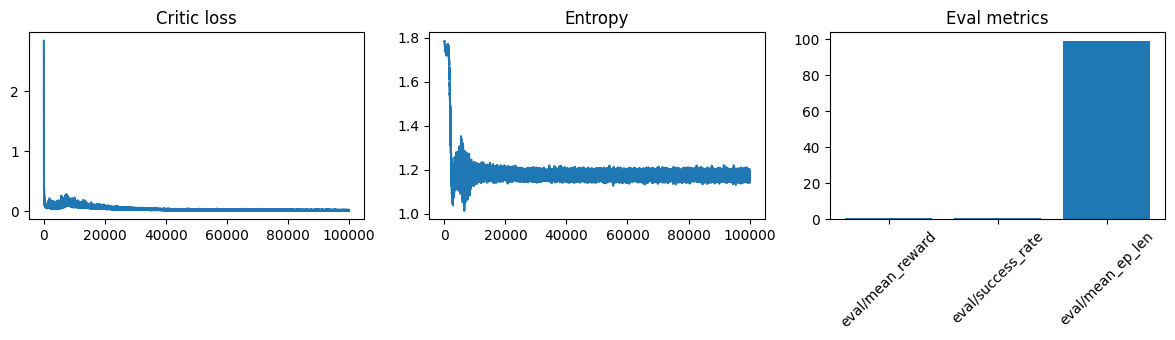

In [12]:

demo_batch = sample_batch_jax(
    jax.random.PRNGKey(SEED + 123),
    cache_jax,
    16,
    INPUT_REPRESENTATION,
    USE_TARGETS,
    value_p_curgoal=VALUE_P_CURGOAL,
    value_p_trajgoal=VALUE_P_TRAJGOAL,
    value_p_randomgoal=VALUE_P_RANDOMGOAL,
    discount=DISCOUNT,
)

metrics = evaluate_policy(final_agent, jax.random.PRNGKey(SEED + 456))
print("Demo batch observations shape:", demo_batch["observations"].shape)
print("Demo batch actions:", np.asarray(demo_batch["actions"])[:8])
print("Evaluation metrics:")
print(metrics)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot(train_log_df["step"], train_log_df.get("critic/critic_loss", train_log_df.iloc[:, 1]))
axes[0].set_title("Critic loss")
axes[1].plot(train_log_df["step"], train_log_df.get("critic/entropy", train_log_df.iloc[:, 1]))
axes[1].set_title("Entropy")
axes[2].bar(list(metrics.keys()), list(metrics.values()))
axes[2].set_title("Eval metrics")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()




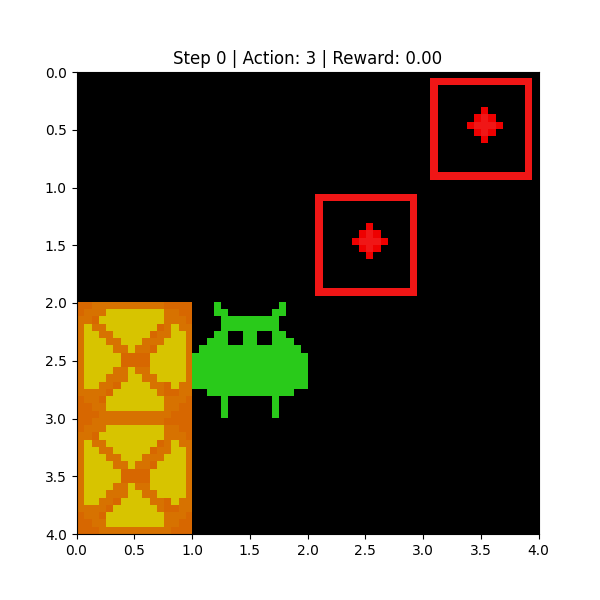

Saved rollout GIF to: /tmp/tmp_5qsg5z0.gif


In [13]:
from IPython.display import Image, display
import matplotlib.animation as animation
import tempfile

rollout_env = wrap_for_eval(create_env(config.env))
rollout_env.step = jax.jit(jax.vmap(rollout_env.step))
rollout_env.reset = jax.jit(jax.vmap(rollout_env.reset))

rollout_key = jax.random.PRNGKey(SEED + 12345)
_, _, timesteps = collect_data(
    final_agent,
    rollout_key,
    rollout_env,
    config.exp.num_envs,
    config.env.episode_length,
    use_targets=config.exp.use_targets,
    input_representation=config.exp.input_representation,
)

timesteps = jax.tree_util.tree_map(lambda x: x.swapaxes(1, 0), timesteps)
completed = jnp.where((timesteps.done | timesteps.truncated).any(axis=1), size=1, fill_value=0)[0]
rollout_index = int(completed[0])
rollout_timesteps = jax.tree_util.tree_map(lambda x: x[rollout_index : rollout_index + 1], timesteps)

fig_gif, ax_gif = plt.subplots(figsize=(6, 6))
anim = animation.FuncAnimation(
    fig_gif,
    lambda frame: rollout_env._env.animate(
        ax_gif,
        rollout_timesteps,
        frame,
        img_prefix=str(REPO_ROOT / "assets"),
    ),
    frames=config.env.episode_length,
    interval=80,
    repeat=False,
)

gif_path = tempfile.NamedTemporaryFile(suffix=".gif", delete=False).name
anim.save(gif_path, writer="pillow")
plt.close(fig_gif)

display(Image(filename=gif_path))
print("Saved rollout GIF to:", gif_path)

Q-comparison summary
States compared: 8
Mean absolute error (all state-actions): 83.7651
Argmax action agreement: 0.500


,state_id,mae,max_error
0,0,86.201496,87.941483
1,1,82.137890,83.574326
2,2,83.047582,84.371002
3,3,84.643777,85.636803
4,4,81.486814,82.544922
5,5,84.982354,85.741165
6,6,85.083827,86.754906
7,7,82.537107,83.652702


,state_id,best_action_learned,best_action_optimal,argmax_match
0,0,DOWN,PICK_UP,False
1,1,DOWN,PICK_UP,False
2,2,PICK_UP,PICK_UP,True
3,3,PICK_UP,PICK_UP,True
4,4,RIGHT,DOWN,False
5,5,DOWN,LEFT,False
6,6,PICK_UP,PICK_UP,True
7,7,DOWN,DOWN,True


,state_id,action,action_id,q_learned,q_optimal,abs_error
0,0,UP,0,86.983902,0.860058,86.123840
1,0,DOWN,1,88.801544,0.860058,87.941483
2,0,LEFT,2,87.077850,0.860058,86.217789
3,0,RIGHT,3,87.029053,0.860058,86.168991
4,0,PICK_UP,4,87.837646,0.877521,86.960129
5,0,PUT_DOWN,5,84.665489,0.868746,83.796745
6,1,UP,0,82.502495,0.817907,81.684586
7,1,DOWN,1,84.400497,0.826169,83.574326
8,1,LEFT,2,83.343475,0.826169,82.517303
9,1,RIGHT,3,82.730629,0.817907,81.912720


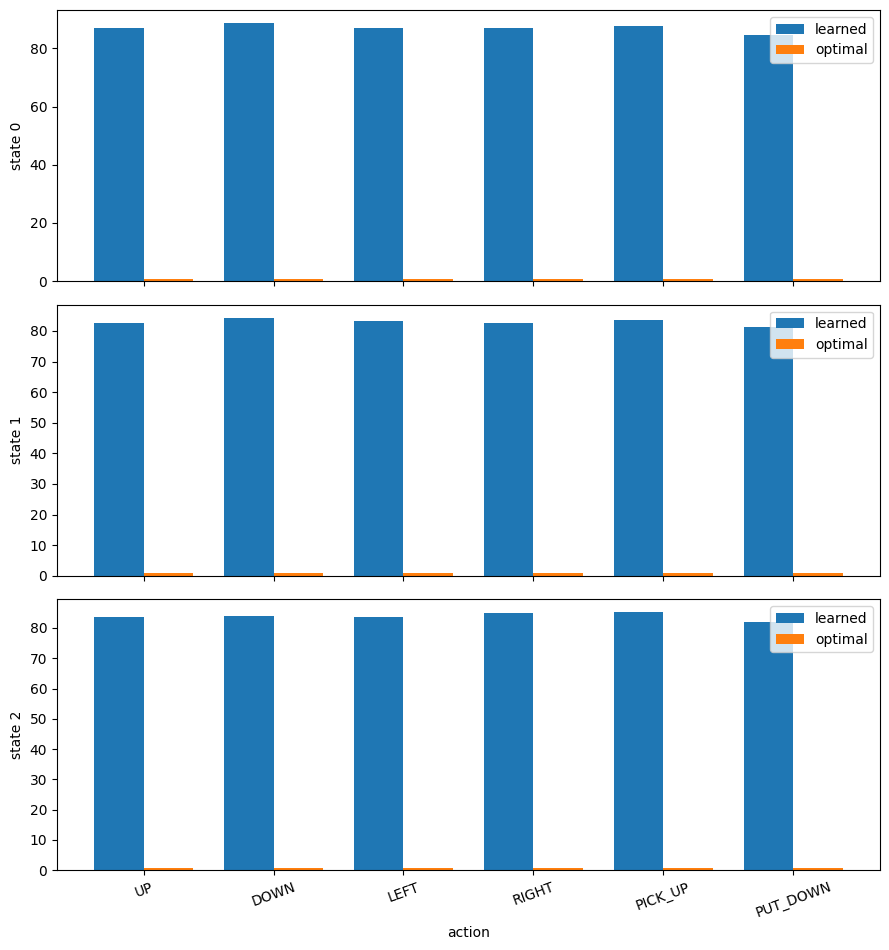

In [14]:
try:
    from optimal_q import calculate_optimal_q_value_and_traj
except ModuleNotFoundError:
    from src.optimal_q import calculate_optimal_q_value_and_traj

ACTION_NAMES = ["UP", "DOWN", "LEFT", "RIGHT", "PICK_UP", "PUT_DOWN"]
NUM_Q_STATES = 8

q_env = BoxMovingEnv(
    grid_size=config.env.grid_size,
    episode_length=config.env.episode_length,
    number_of_boxes_min=config.env.number_of_boxes_min,
    number_of_boxes_max=config.env.number_of_boxes_max,
    number_of_moving_boxes_max=config.env.number_of_moving_boxes_max,
    level_generator=config.env.level_generator,
    generator_special=config.env.generator_special,
    quarter_size=config.env.quarter_size,
    terminate_when_success=False,
)


def learned_q_vector(agent, state) -> np.ndarray:
    obs = jnp.asarray(state.grid)[None, ...]
    goals = jnp.asarray(state.goal)[None, ...]
    if not USE_TARGETS:
        obs = remove_targets(obs)
        goals = remove_targets(goals)

    obs_enc = encode_grid_inputs(obs, INPUT_REPRESENTATION)
    goals_enc = encode_grid_inputs(goals, INPUT_REPRESENTATION)
    all_actions = jnp.arange(6, dtype=jnp.int32)[None, :]

    qs = jax.vmap(agent.network.select("critic"), in_axes=(None, None, 1))(obs_enc, goals_enc, all_actions)
    if len(qs.shape) == 2:
        qs = qs[:, None, ...]
    qs = qs.mean(axis=1).transpose(1, 0)  # B x A
    return np.asarray(qs[0], dtype=np.float32)


def optimal_q_vector(env: BoxMovingEnv, state, discount: float) -> np.ndarray:
    q_vals = np.zeros((6,), dtype=np.float32)
    for action in range(6):
        next_state, reward, _, _ = env.step(state, int(action))
        _, cont_q = calculate_optimal_q_value_and_traj(env, next_state, discount=discount)
        q_vals[action] = float(reward) + float(discount) * float(cont_q)
    return q_vals


compare_key = jax.random.PRNGKey(SEED + 777)
compare_keys = jax.random.split(compare_key, NUM_Q_STATES)

rows = []
state_pairs = []
for state_id, key in enumerate(compare_keys):
    state, _ = q_env.reset(key)
    q_learned = learned_q_vector(final_agent, state)
    q_opt = optimal_q_vector(q_env, state, float(config.agent.discount))

    state_pairs.append((state_id, q_learned, q_opt))
    for a in range(6):
        rows.append(
            {
                "state_id": state_id,
                "action": ACTION_NAMES[a],
                "action_id": a,
                "q_learned": float(q_learned[a]),
                "q_optimal": float(q_opt[a]),
                "abs_error": float(abs(q_learned[a] - q_opt[a])),
            }
        )

q_df = pd.DataFrame(rows)
state_summary = (
    q_df.groupby("state_id")
    .agg(mae=("abs_error", "mean"), max_error=("abs_error", "max"))
    .reset_index()
)

argmax_rows = []
for state_id, q_learned, q_opt in state_pairs:
    argmax_rows.append(
        {
            "state_id": state_id,
            "best_action_learned": ACTION_NAMES[int(np.argmax(q_learned))],
            "best_action_optimal": ACTION_NAMES[int(np.argmax(q_opt))],
            "argmax_match": bool(np.argmax(q_learned) == np.argmax(q_opt)),
        }
    )
argmax_df = pd.DataFrame(argmax_rows)

print("Q-comparison summary")
print(f"States compared: {NUM_Q_STATES}")
print(f"Mean absolute error (all state-actions): {q_df['abs_error'].mean():.4f}")
print(f"Argmax action agreement: {argmax_df['argmax_match'].mean():.3f}")

display(state_summary)
display(argmax_df)
display(q_df.head(18))

num_plot_states = min(3, NUM_Q_STATES)
fig, axes = plt.subplots(num_plot_states, 1, figsize=(9, 3.2 * num_plot_states), sharex=True)
if num_plot_states == 1:
    axes = [axes]

for i in range(num_plot_states):
    state_id, q_learned, q_opt = state_pairs[i]
    x = np.arange(6)
    width = 0.38
    axes[i].bar(x - width / 2, q_learned, width=width, label="learned")
    axes[i].bar(x + width / 2, q_opt, width=width, label="optimal")
    axes[i].set_ylabel(f"state {state_id}")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ACTION_NAMES, rotation=20)
    axes[i].legend()

axes[-1].set_xlabel("action")
plt.tight_layout()
plt.show()